# imports & setup

In [1]:
from pathlib import Path
from typing import Any, Literal
import json

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors
from tqdm import tqdm

# scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
import sklearn.base
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import parse_cls, DistanceTensorResult
from attention_motifs.features.plotting import plot_embedding
from attention_motifs.features.head_analysis import filter_umap_warns
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/")

# load dists

In [4]:
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "features" / "head_dists.zanj"
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)

[ <ipykernel>:4 ] HEAD_DISTS.distances: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64
[ <ipykernel>:5 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


array([[ 0.        ,  8.69202432,  9.54040428, ..., 12.25940865,
        12.16375817, 12.23178058],
       [ 8.69202432,  0.        ,  9.8659314 , ...,  9.98180279,
         9.99545272,  9.95879912],
       [ 9.54040428,  9.8659314 ,  0.        , ...,  8.9271944 ,
         8.64037894,  8.91942945],
       ...,
       [12.25940865,  9.98180279,  8.9271944 , ...,  0.        ,
         1.75838832,  1.64093945],
       [12.16375817,  9.99545272,  8.64037894, ...,  1.75838832,
         0.        ,  1.69310037],
       [12.23178058,  9.95879912,  8.91942945, ...,  1.64093945,
         1.69310037,  0.        ]])

In [5]:
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

# heirarchical clustering

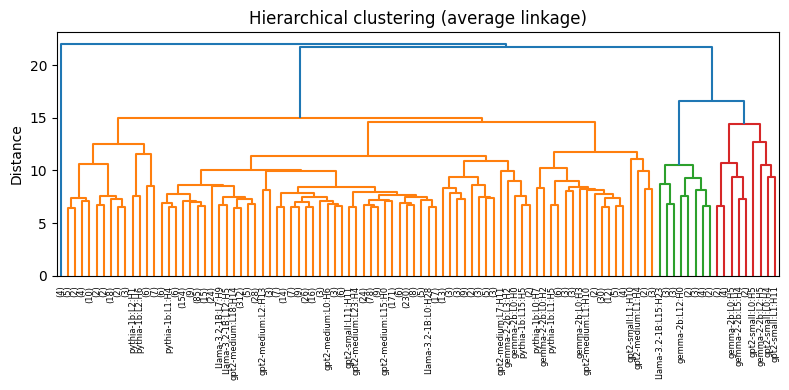

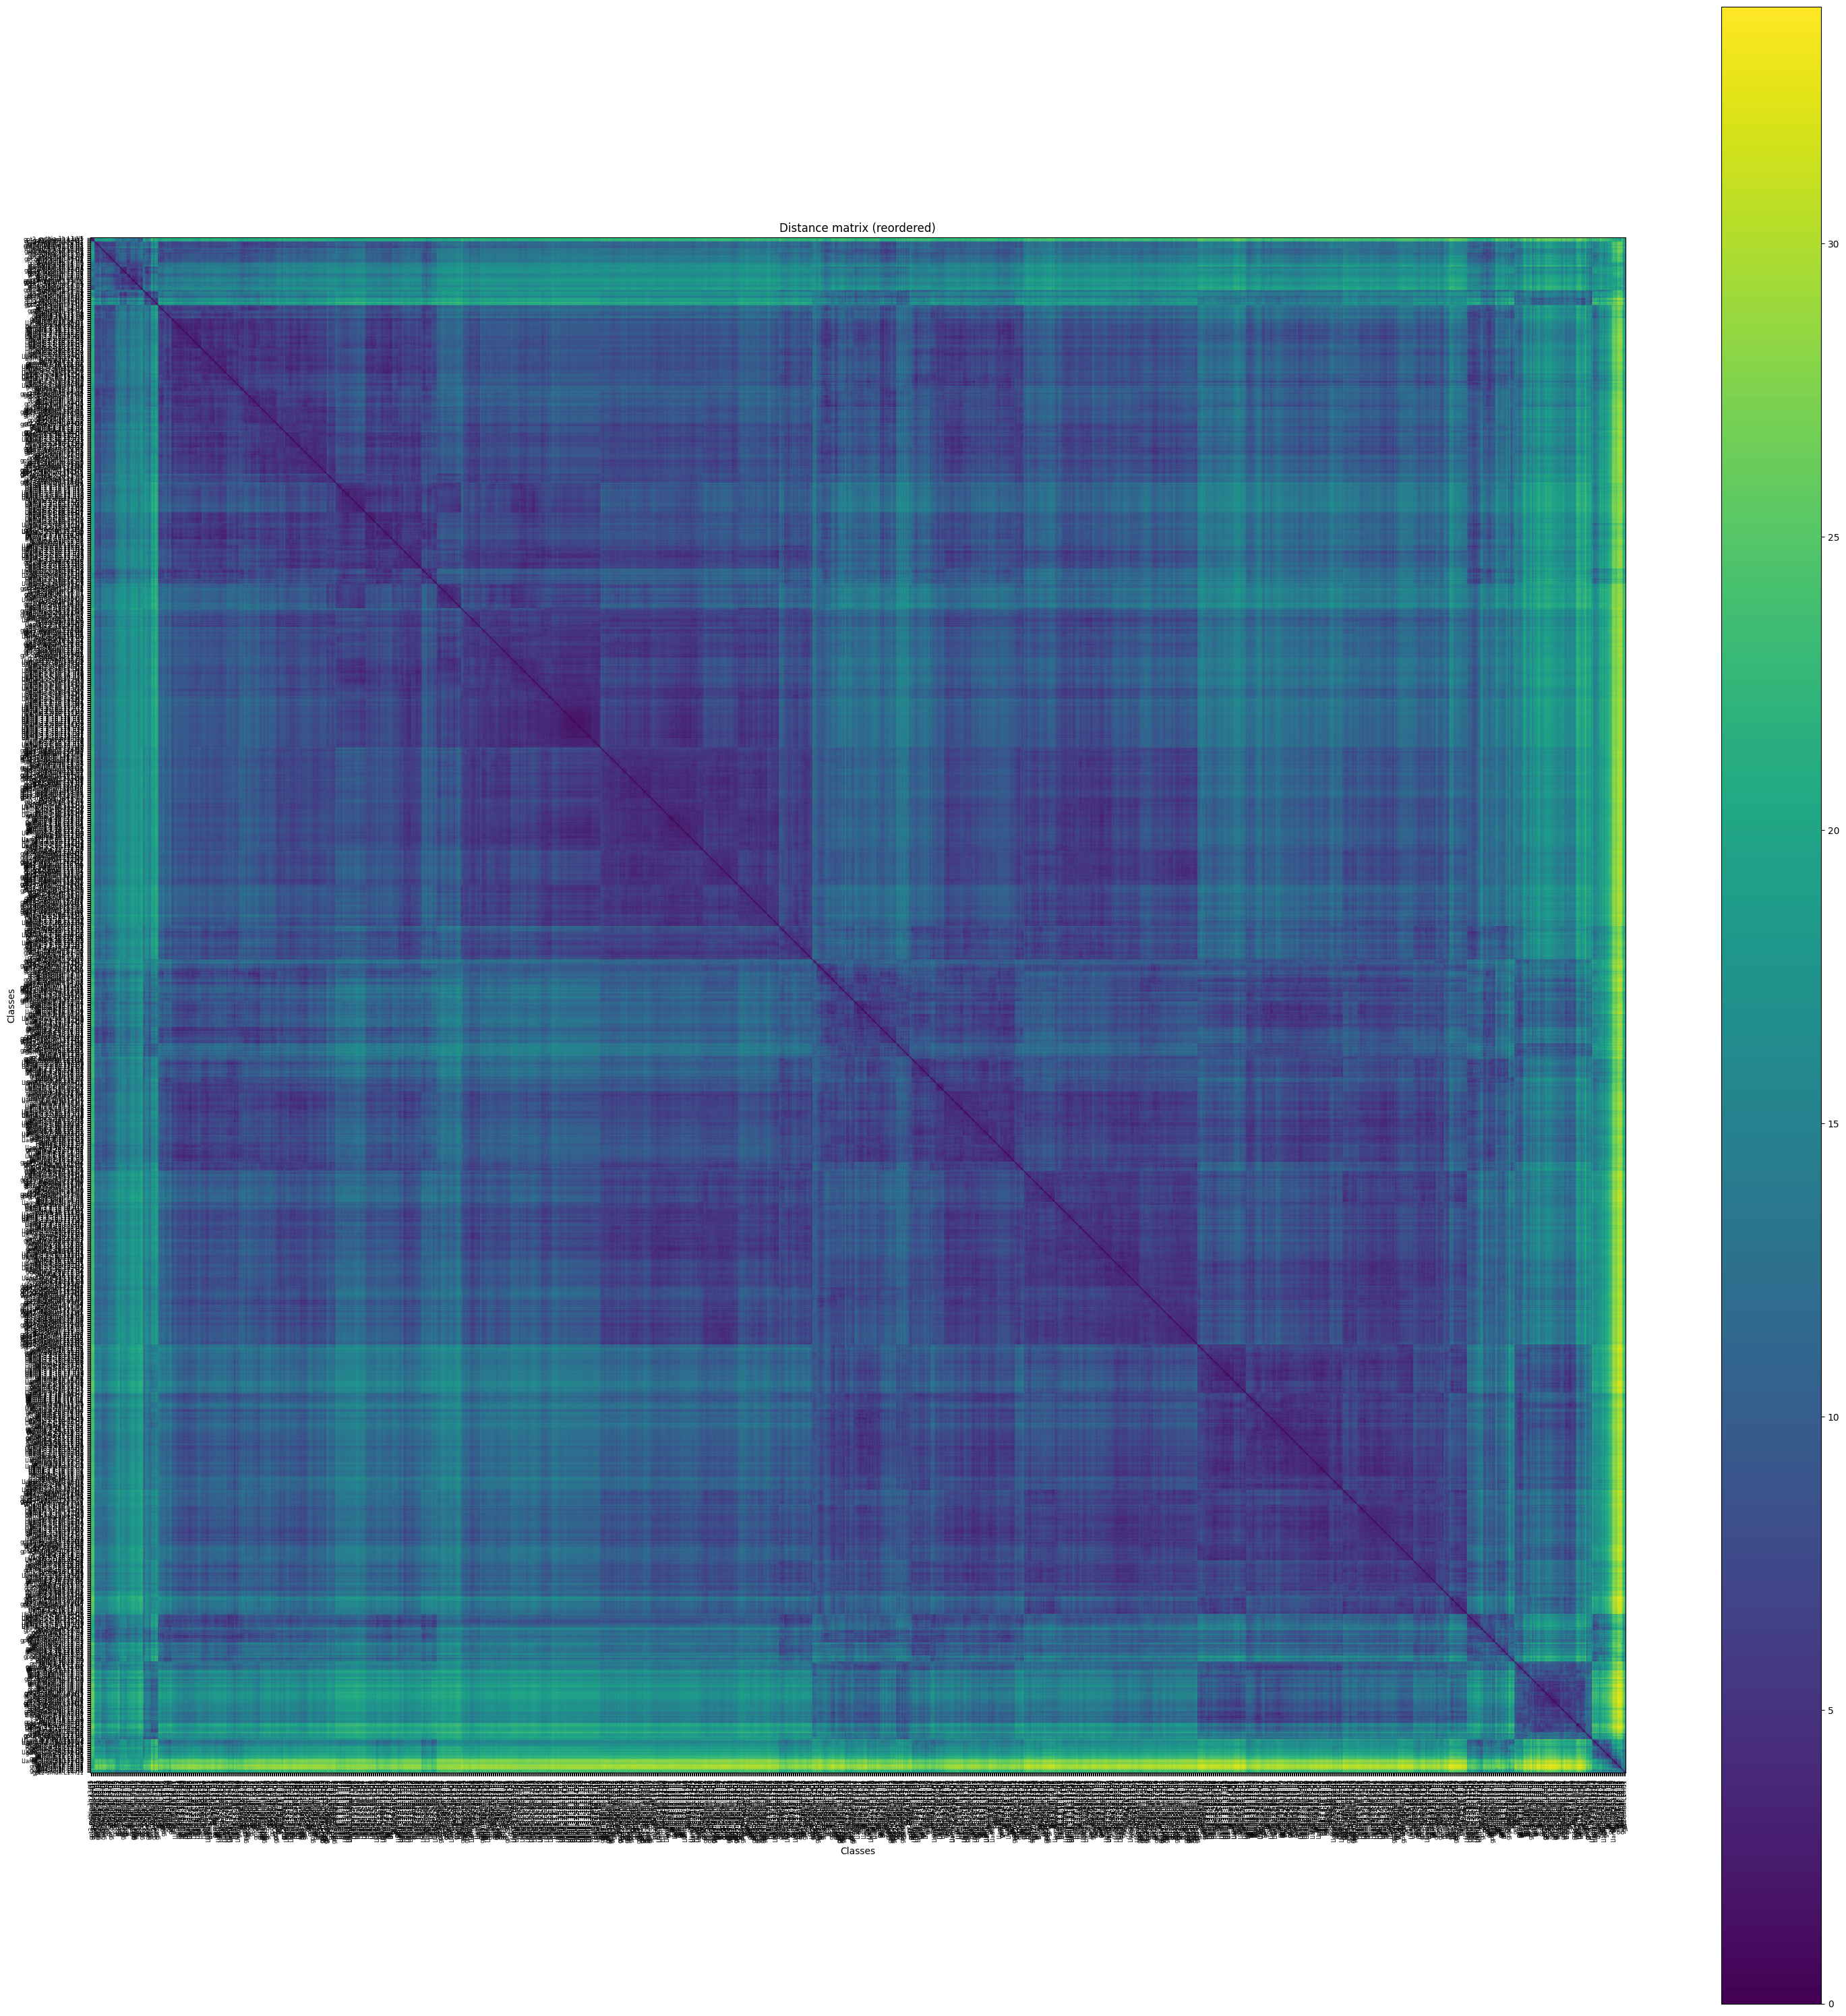

[ <ipykernel>:128 ] linkages: μ=765.16 σ=977.06 x̃=65.50 R=[0.00,3037.00] ℙ=|█▁▁▁▁▁▁| shape=(1519,4) dtype=float64


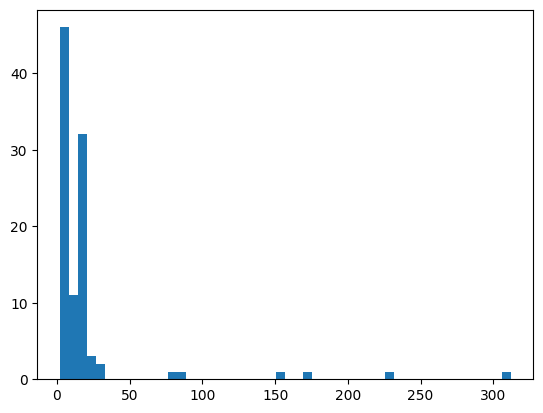

{
  "0": 4,
  "1.0.0.0.0.0.0": 5,
  "1.0.0.0.0.0.1": 2,
  "1.0.0.0.0.1.0": 4,
  "1.0.0.0.0.1.1": 10,
  "1.0.0.0.1.0.0": 2,
  "1.0.0.0.1.0.1": 2,
  "1.0.0.0.1.1.0": 18,
  "1.0.0.0.1.1.1.0": 2,
  "1.0.0.0.1.1.1.1": 3,
  "1.0.0.1.0.0": 15,
  "1.0.0.1.0.1": 15,
  "1.0.0.1.1.0": 6,
  "1.0.0.1.1.1": 7,
  "1.0.1.0.0.0.0.0.0": 6,
  "1.0.1.0.0.0.0.0.1.0": 15,
  "1.0.1.0.0.0.0.0.1.1": 6,
  "1.0.1.0.0.0.0.1.0": 154,
  "1.0.1.0.0.0.0.1.1.0": 9,
  "1.0.1.0.0.0.0.1.1.1.0": 85,
  "1.0.1.0.0.0.0.1.1.1.1": 15,
  "1.0.1.0.0.0.1.0": 24,
  "1.0.1.0.0.0.1.1.0.0": 18,
  "1.0.1.0.0.0.1.1.0.1": 19,
  "1.0.1.0.0.0.1.1.1.0.0": 19,
  "1.0.1.0.0.0.1.1.1.0.1": 312,
  "1.0.1.0.0.0.1.1.1.1.0": 5,
  "1.0.1.0.0.0.1.1.1.1.1": 28,
  "1.0.1.0.0.1.0.0": 18,
  "1.0.1.0.0.1.0.1": 3,
  "1.0.1.0.0.1.1.0.0.0": 7,
  "1.0.1.0.0.1.1.0.0.1": 14,
  "1.0.1.0.0.1.1.0.1.0.0.0": 7,
  "1.0.1.0.0.1.1.0.1.0.0.1": 9,
  "1.0.1.0.0.1.1.0.1.0.1.0": 26,
  "1.0.1.0.0.1.1.0.1.0.1.1": 16,
  "1.0.1.0.0.1.1.0.1.1.0": 3,
  "1.0.1.0.0.1.1.0.1.1.1.0":

In [6]:
def plot_hclust(
	dist_mat: Float[np.ndarray, "h h"],
	labels: list[str],
	*,
	method: str = "average",
	leaf_font_size: int = 6,
	truncate: int | None = None,
	show_heatmap: bool = True,
) -> tuple[np.ndarray, list[str], dict[str, Any]]:
	"""Hierarchical clustering dendrogram (plus optional heat-map).

	# Parameters
	 - `dist_mat : Float[np.ndarray, "h h"]`
	    Square distance matrix (symmetric, zero diagonal).
	 - `labels : list[str]`
	    Observation names, length `h`.
	 - `method : str`
	    Linkage criterion for `scipy.cluster.hierarchy.linkage`.
	 - `leaf_font_size : int`
	    Tick-label font size.
	 - `truncate : int | None`
	    If given, plot the dendrogram in *last-p* mode with `p = truncate`.
	 - `show_heatmap : bool`
	    Draw reordered distance matrix.
	 - `figsize : tuple[int, int] | None`
	    Figure size; if `None`, pick a reasonable default.

	# Returns
	 - `np.ndarray`
	    Linkage matrix `Z` (`h - 1`, 4).
	 - `dict[str, Any]`
	    Dot-list representation of the tree **as actually plotted**
	    (clusters are collapsed when `truncate` is used).
	"""
	h: int = dist_mat.shape[0]

	# ---------- sanity checks
	if dist_mat.shape != (h, h):
		raise ValueError("dist_mat must be square")
	if len(labels) != h:
		raise ValueError("labels length must match dist_mat")
	if not np.allclose(dist_mat, dist_mat.T):
		raise ValueError("dist_mat must be symmetric")
	if not np.all(np.diag(dist_mat) == 0):
		raise ValueError("dist_mat diagonal must be zero")

	# ---------- linkage
	condensed: Float[np.ndarray, "h*(h-1)//2"] = squareform(dist_mat, checks=False)
	Z: np.ndarray = linkage(condensed, method=method)

	# ---------- dendrogram
	_, ax_dend = plt.subplots(figsize=(8, 4))
	dend_kw: dict[str, object] = {
		"labels": labels,
		"leaf_rotation": 90,
		"leaf_font_size": leaf_font_size,
		"distance_sort": "ascending",
	}
	if truncate is not None:
		dend_kw.update({"truncate_mode": "lastp", "p": truncate})

	dendro: dict[str, Any] = dendrogram(Z, **dend_kw, ax=ax_dend)
	ax_dend.set_ylabel("Distance")
	ax_dend.set_title(f"Hierarchical clustering ({method} linkage)")
	# ax_dend.set_ylim(7, 27)
	plt.tight_layout()
	plt.show()

	# ---------- helpers
	def _members(node_id: int, *, n: int = h) -> list[int]:
		"""Return all original leaf indices contained in `node_id`."""
		if node_id < n:
			return [node_id]
		left: int = int(Z[node_id - n, 0])
		right: int = int(Z[node_id - n, 1])
		return _members(left, n=n) + _members(right, n=n)

	visible_ids: set[int] = set(dendro["leaves"])

	# ---------- heat-map
	order: list[int]
	if truncate is None:
		order = list(dendro["leaves"])
	else:
		order = [idx for node in dendro["leaves"] for idx in _members(node)]
	labels_ordered: list[str] = [labels[i] for i in order]
	if show_heatmap:
		reordered: Float[np.ndarray, "h h"] = dist_mat[np.ix_(order, order)]

		_, ax_hm = plt.subplots(figsize=(30, 30))
		im = ax_hm.imshow(reordered, aspect="auto")
		ax_hm.set_xticks(np.arange(h))
		ax_hm.set_yticks(np.arange(h))
		ax_hm.set_xticklabels(labels_ordered, rotation=90, fontsize=leaf_font_size)
		ax_hm.set_yticklabels(labels_ordered, fontsize=leaf_font_size)
		ax_hm.set_xlabel("Classes")
		ax_hm.set_ylabel("Classes")
		ax_hm.set_title("Distance matrix (reordered)")
		ax_hm.set_aspect("equal")
		plt.colorbar(im, ax=ax_hm)
		plt.tight_layout()
		plt.show()

	# ---------- dot-list
	def _dot_tree(node_id: int, path: str = "") -> dict[str, Any]:
		key: str = path.rstrip(".") or "root"
		if node_id in visible_ids:  # displayed leaf/cluster
			mem: list[int] = _members(node_id)
			return {key: labels[mem[0]] if len(mem) == 1 else [labels[m] for m in mem]}
		left, right = (int(x) for x in Z[node_id - h, :2])
		dot: dict[str, Any] = {}
		dot.update(_dot_tree(left, f"{path}0."))
		dot.update(_dot_tree(right, f"{path}1."))
		return dot

	tree_dict: dict[str, Any] = _dot_tree(2 * h - 2)

	return Z, labels_ordered, tree_dict


linkages, labels_sorted, tree = plot_hclust(
	HEAD_DISTS.mean_dists,
	labels=HEAD_DISTS.cls_values,
	truncate=100,
	# show_heatmap=False,
)

dbg_tensor(linkages)
leaf_lens: dict[str, int] = {k: len(v) for k, v in tree.items()}
plt.hist(
	leaf_lens.values(),
	bins=50,
)
plt.show()
print(
	json.dumps(
		leaf_lens,
		indent=2,
	)
)

In [7]:
import itertools

tree_known_types: dict[str, set[str]] = {
	k: set(
		itertools.chain.from_iterable(
			[ATTENTIONPEDIA.head_to_types().get(h, ["unknown"]) for h in v]
		)
	)
	for k, v in tree.items()
}
tree_known_types

{'0': {'IOI:Previous Token', 'SAE-survey:Previous Token', 'unknown'},
 '1.0.0.0.0.0.0': {'unknown'},
 '1.0.0.0.0.0.1': {'unknown'},
 '1.0.0.0.0.1.0': {'unknown'},
 '1.0.0.0.0.1.1': {'unknown'},
 '1.0.0.0.1.0.0': {'unknown'},
 '1.0.0.0.1.0.1': {'unknown'},
 '1.0.0.0.1.1.0': {'unknown'},
 '1.0.0.0.1.1.1.0': {'unknown'},
 '1.0.0.0.1.1.1.1': {'IOI:Previous Token', 'unknown'},
 '1.0.0.1.0.0': {'unknown'},
 '1.0.0.1.0.1': {'unknown'},
 '1.0.0.1.1.0': {'unknown'},
 '1.0.0.1.1.1': {'unknown'},
 '1.0.1.0.0.0.0.0.0': {'unknown'},
 '1.0.1.0.0.0.0.0.1.0': {'unknown'},
 '1.0.1.0.0.0.0.0.1.1': {'unknown'},
 '1.0.1.0.0.0.0.1.0': {'IOI:S-Inhibition', 'unknown'},
 '1.0.1.0.0.0.0.1.1.0': {'unknown'},
 '1.0.1.0.0.0.0.1.1.1.0': {'IOI:Induction', 'unknown'},
 '1.0.1.0.0.0.0.1.1.1.1': {'unknown'},
 '1.0.1.0.0.0.1.0': {'IOI:Induction',
  'SAE-survey:Induction',
  'greater-than:YY Identifier',
  'unknown'},
 '1.0.1.0.0.0.1.1.0.0': {'unknown'},
 '1.0.1.0.0.0.1.1.0.1': {'unknown'},
 '1.0.1.0.0.0.1.1.1.0.0': {'u

In [8]:
known_types_to_leaf: dict[str, set[str]] = {
	t: set([head for head, types in tree_known_types.items() if t in types])
	for t in [*ATTENTIONPEDIA.type_to_heads().keys(), "unknown"]
}
known_types_to_leaf

{'IOI:Previous Token': {'0', '1.0.0.0.1.1.1.1'},
 'IOI:Duplicate Token': {'1.0.1.0.0.0.1.1.1.1.1',
  '1.0.1.1.0.1.1.1.1.1.1.1.1',
  '1.1.1.0.1.1.1'},
 'IOI:Induction': {'1.0.1.0.0.0.0.1.1.1.0',
  '1.0.1.0.0.0.1.0',
  '1.0.1.0.0.0.1.1.1.0.1',
  '1.0.1.0.0.1.1.1.1.0.1.1'},
 'IOI:S-Inhibition': {'1.0.1.0.0.0.0.1.0',
  '1.0.1.0.0.0.1.1.1.0.1',
  '1.0.1.0.0.1.1.1.1.1.0.1.0'},
 'IOI:Negative Name Mover': {'1.0.1.0.0.1.1.1.1.0.1.1'},
 'IOI:Name Mover': {'1.0.1.0.0.0.1.1.1.0.1'},
 'IOI:Backup Name Mover': {'1.0.1.0.0.0.1.1.1.0.1', '1.0.1.0.0.1.1.1.1.0.1.1'},
 'SAE-survey:Induction': {'1.0.1.0.0.0.1.0', '1.0.1.0.0.0.1.1.1.0.1'},
 'SAE-survey:Previous Token': {'0'},
 'SAE-survey:Copy Suppression': {'1.0.1.0.0.1.1.1.1.0.1.1'},
 'SAE-survey:Duplicate Token': {'1.0.1.0.0.0.1.1.1.1.1'},
 'SAE-survey:Successor': {'1.0.1.0.0.0.1.1.1.0.1'},
 'SAE-survey:Long Range Context Tracking': {'1.0.1.0.0.0.1.1.1.0.1'},
 'greater-than:YY Identifier': {'1.0.1.0.0.0.1.0',
  '1.0.1.0.0.0.1.1.1.0.1',
  '1.0.1.0.0.1.1